In [1]:
import sys, os
from pathlib import Path
import numpy as np


ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from env.drone_env        import DroneEnv2D
from env.discrete_wrapper import DiscreteWrapper

from funcs.vis import value_function_vis
from algos.classical.dynamic_programming import build_model, policy_iteration, value_iteration
from algos.classical.dynamic_programming import policy_improvement


In [11]:
base_0 = DroneEnv2D(world_size=20.0, max_steps=300, level=0)
env_0 = DiscreteWrapper(base_0, grid_size=20)

print(f'States: {env_0.n_states}  Actions: {env_0.n_actions}')



States: 400  Actions: 25


## 1. Sanity check — random policy

> Establishes a baseline. Every algorithm below should beat this.


In [3]:
rewards = []
for _ in range(200):
    s, _ = env_0.reset()
    G = 0.0
    while True:
        a = env_0.action_space.sample()
        s, r, t1, t2, _ = env_0.step(a)
        G += r
        if t1 or t2:
            break
    rewards.append(G)

print(f'Random policy  mean reward: {np.mean(rewards):.2f}')


Random policy  mean reward: -27.54


## 2. Dynamic Programming — Policy Iteration & Value Iteration

Requires a model. We approximate P(s'|s,a) and R(s,a) by sampling
the discrete env exhaustively, then solve the Bellman equations exactly.

Note: this builds a model over 400 states × 9 actions, which takes
a couple of minutes. Skip this cell if you're short on time —
the other algorithms don't depend on it.

In [2]:

P_0, R_0, T_0  = build_model(env_0, n_samples=3)

# pi_policy, V_pi = policy_iteration(P, R, gamma=0.95, theta=1e-4)
vi_policy_0, V_vi_0 = value_iteration(P_0, R_0, T_0,  gamma=0.95, theta=1e-4)

# print(f'\nV_pi range : [{V_pi.min():.2f}, {V_pi.max():.2f}]')
print(f'V_vi range : [{V_vi_0.min():.2f}, {V_vi_0.max():.2f}]')

NameError: name 'env_0' is not defined

In [10]:
import pygame

base_vis_0 = DroneEnv2D(world_size=20, level=0, render_mode="human", fps=8)
env_vis_0 = DiscreteWrapper(base_vis_0, grid_size=20)

state, info = env_vis_0.reset(seed=42)
total_reward = 0
env_vis_0.render()

running = True
for step in range(500):
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
            break
    if not running:
        break
    
    action = int(np.argmax(vi_policy_0[state]))     # <-- replaces env.action_space.sample()
    state, reward, terminated, truncated, info = env_vis_0.step(action)
    total_reward += reward
    env_vis_0.render()
    if terminated or truncated:
        print(f"done at step {step}, reward={total_reward:.2f}")
        break

env_vis_0.close()

done at step 58, reward=118.87


#### level 2

In [2]:
base_1 = DroneEnv2D(world_size=20.0, max_steps=300, level=1)
env_1 = DiscreteWrapper(base_1, grid_size=20)


P_1, R_1, terminals   = build_model(env_1)

# pi_policy, V_pi = policy_iteration(P, R, gamma=0.95, theta=1e-4)
vi_policy_1, V_vi_1 = value_iteration(P_1, R_1, terminals, gamma=0.95, theta=1e-4)

# print(f'\nV_pi range : [{V_pi.min():.2f}, {V_pi.max():.2f}]')
print(f'V_vi range : [{V_vi_1.min():.2f}, {V_vi_1.max():.2f}]')


yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
Terminal states: 26 / 400
Building model...


100%|██████████| 400/400 [00:00<00:00, 513.94it/s]



=== Value Iteration ===
  Sweep    0 | Δ = 100.239883
  Sweep   50 | Δ = 7.712955
  Sweep  100 | Δ = 0.593473
  Sweep  150 | Δ = 0.045665
  Sweep  200 | Δ = 0.003514
  Sweep  250 | Δ = 0.000270
  Converged in 271 sweeps.
V_vi range : [0.00, 2004.80]


In [5]:
import pygame 

base_vis_1 = DroneEnv2D(world_size=20, level=1, render_mode="human", fps=8)
env_vis_1 = DiscreteWrapper(base_vis_1, grid_size=20)

state, info = env_vis_1.reset(seed=42)
total_reward = 0
env_vis_1.render()

running = True
for step in range(500):
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
            break
    if not running:
        break
    
    action = int(np.argmax(vi_policy_1[state]))     # <-- replaces env.action_space.sample()
    state, reward, terminated, truncated, info = env_vis_1.step(action)
    total_reward += reward
    env_vis_1.render()
    if terminated or truncated:
        print(f"done at step {step}, reward={total_reward:.2f}")
        break

env_vis_1.close()

done at step 16, reward=-94.50


c:\Users\kajou\OneDrive\Desktop\W-work\RL-101\.venv\lib\site-packages\ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


20


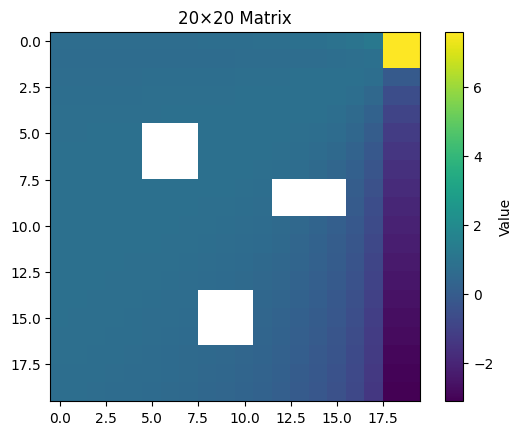

In [3]:
_ = value_function_vis(np.log(V_vi_1))

In [4]:
print(V_vi_1[terminals])
print(terminals.sum())
print("V at goal cell:", V_vi_1[env_1.goal_state()])        # must be >> 0
print(V_vi_1.max())

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
26
V at goal cell: 2002.0602337842124
2004.79582697459


In [19]:
goal_s = env_1.pos_to_state(np.array([19.0, 1.0]))
print("Goal state index:", goal_s)
print("Goal state pos:", env_1.state_to_pos(goal_s))

Goal state index: 39
Goal state pos: [19.5  1.5]


In [8]:
env = env_1
raw = env.env.unwrapped

print("=== DEBUG TERMINAL SCAN ===")
print(f"curriculum_level : {raw.level}")
print(f"obstacles        : {raw.obstacles}")
print(f"world_size       : {raw.world_size}")

# Test a few specific positions manually
test_positions = {
    "bottom-left (start)" : np.array([1.0,  19.0]),
    "top-right (goal)"    : np.array([19.0,  1.0]),
    "center"              : np.array([10.0, 10.0]),
}

# Add obstacle centers if obstacles exist
for i, obs in enumerate(raw.obstacles):
    cx = obs.x + obs.w / 2
    cy = obs.y + obs.h / 2
    test_positions[f"obstacle_{i}_center"] = np.array([cx, cy])

for name, pos in test_positions.items():
    raw.pos = pos.copy()
    col = raw._check_collision()
    print(f"  {name:30s} pos={pos}  collision={col}")

# Now scan all states and print the first 5 that should be terminal
print("\n=== GRID CELL SCAN ===")
found = 0
for s in range(env.n_states):
    pos = env.state_to_pos(s)
    raw.pos = pos.copy()
    col = raw._check_collision()
    if col:
        print(f"  terminal state {s:4d}  pos={pos}  collision={col}")
        found += 1
    if found >= 5:
        print("  ...")
        break

if found == 0:
    print("  NO terminal states found — deep problem, see below")
    # Check state_to_pos output
    print(f"\n  state_to_pos(0)   = {env.state_to_pos(0)}")
    print(f"  state_to_pos(19)  = {env.state_to_pos(19)}")
    print(f"  state_to_pos(380) = {env.state_to_pos(380)}")
    print(f"  state_to_pos(399) = {env.state_to_pos(399)}")

=== DEBUG TERMINAL SCAN ===
curriculum_level : 1
obstacles        : [Rect(x=5.0, y=5.0, w=3.0, h=3.0), Rect(x=12.0, y=8.0, w=4.0, h=2.0), Rect(x=8.0, y=14.0, w=3.0, h=3.0)]
world_size       : 20.0
  bottom-left (start)            pos=[ 1. 19.]  collision=False
  top-right (goal)               pos=[19.  1.]  collision=False
  center                         pos=[10. 10.]  collision=False
  obstacle_0_center              pos=[6.5 6.5]  collision=True
  obstacle_1_center              pos=[14.  9.]  collision=True
  obstacle_2_center              pos=[ 9.5 15.5]  collision=True

=== GRID CELL SCAN ===
  terminal state  105  pos=[5.5 5.5]  collision=True
  terminal state  106  pos=[6.5 5.5]  collision=True
  terminal state  107  pos=[7.5 5.5]  collision=True
  terminal state  125  pos=[5.5 6.5]  collision=True
  terminal state  126  pos=[6.5 6.5]  collision=True
  ...


-------------
------------------

In [ ]:

# # %% [markdown]
# # ## 1. Sanity check — random policy

# # Establishes a baseline. Every algorithm below should beat this.

# # %%
# rewards = []
# for _ in range(200):
#     s, _ = env.reset()
#     G = 0.0
#     while True:
#         a = env.action_space.sample()
#         s, r, t1, t2, _ = env.step(a)
#         G += r
#         if t1 or t2:
#             break
#     rewards.append(G)

# print(f'Random policy  mean reward: {np.mean(rewards):.2f}')


# # %% [markdown]
# # ## 2. Q-Learning
# #
# # Off-policy TD control.
# # δ = r + γ max_a' Q(s',a') - Q(s,a)

# # %%
# from algos.classical import QLearning

# ql = QLearning(env.n_states, env.n_actions, gamma=0.99, alpha=0.1)
# ql.train(make_env(), n_episodes=3000, log_every=300)


# # %% [markdown]
# # ## 3. SARSA — compare with Q-Learning
# #
# # On-policy TD control.
# # δ = r + γ Q(s',a') - Q(s,a)   where a' is sampled from ε-greedy

# # %%
# from algos.classical import SARSA

# sarsa = SARSA(env.n_states, env.n_actions, gamma=0.99, alpha=0.1)
# sarsa.train(make_env(), n_episodes=3000, log_every=300)


# # %% [markdown]
# # ## 4. Monte Carlo
# #
# # Model-free, learns from complete episodes.
# # Q(s,a) ← Q(s,a) + α [G_t - Q(s,a)]

# # %%
# from algos.classical import MonteCarloControl

# mc = MonteCarloControl(env.n_states, env.n_actions,
#                        gamma=0.99, alpha=0.05, first_visit=True)
# mc.train(make_env(), n_episodes=2000, log_every=200)


# # %% [markdown]
# # ## 5. Dynamic Programming — Policy Iteration & Value Iteration
# #
# # Requires a model. We approximate P(s'|s,a) and R(s,a) by sampling
# # the discrete env exhaustively, then solve the Bellman equations exactly.
# #
# # Note: this builds a model over 400 states × 9 actions, which takes
# # a couple of minutes. Skip this cell if you're short on time —
# # the other algorithms don't depend on it.

# # %%
# from algos.classical import build_model, policy_iteration, value_iteration
# from algos.classical.dynamic_programming import policy_improvement

# dp_env = make_env(level=0)
# P, R   = build_model(dp_env, n_samples=3)

# pi_policy, V_pi = policy_iteration(P, R, gamma=0.99, theta=1e-4)
# vi_policy, V_vi = value_iteration(P, R, gamma=0.99, theta=1e-4)

# print(f'\nV_pi range : [{V_pi.min():.2f}, {V_pi.max():.2f}]')
# print(f'V_vi range : [{V_vi.min():.2f}, {V_vi.max():.2f}]')


# # %% [markdown]
# # ## 6. Learning curves — all online algorithms
# #
# # Things to look for:
# # - **Q-Learning** often rises fastest early — more aggressive off-policy learning.
# # - **SARSA** may be slightly lower but more stable — it accounts for its own exploration.
# # - **Monte Carlo** starts slower — needs full episodes before any update happens.

# # %%
# def smooth(x, w=50):
#     return np.convolve(x, np.ones(w) / w, mode='valid')

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# for agent, label in [(ql, 'Q-Learning'), (sarsa, 'SARSA'), (mc, 'Monte Carlo')]:
#     ax1.plot(smooth(agent.episode_rewards), label=label)
#     ax2.plot(smooth(agent.episode_lengths), label=label)

# for ax, title, ylabel in [(ax1, 'Episode Reward', 'reward'),
#                            (ax2, 'Episode Length', 'steps')]:
#     ax.set_title(title)
#     ax.set_xlabel('episode')
#     ax.set_ylabel(ylabel)
#     ax.legend()
#     ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()


# # %% [markdown]
# # ## 7. Visualise the Q-table as a heatmap + policy arrows
# #
# # V(s) = max_a Q(s,a)  — shows how "good" each grid cell is.
# # π*(s) = argmax_a Q(s,a)  — shows which direction the agent thrusts from each cell.

# # %%
# V  = np.max(ql.Q, axis=1).reshape(env.grid_size, env.grid_size)
# PI = np.argmax(ql.Q, axis=1).reshape(env.grid_size, env.grid_size)

# # Action index -> (dx, dy) direction, matching DiscreteWrapper.ACTION_VECTORS
# DX = [ 0, 1, 1, 1, 0, -1, -1, -1, 0]
# DY = [-1, -1, 0, 1, 1,  1,  0, -1, 0]

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Value heatmap
# im = axes[0].imshow(V, origin='upper', cmap='viridis')
# plt.colorbar(im, ax=axes[0])
# axes[0].set_title('V(s) = max_a Q(s,a)  —  Q-Learning')

# # Policy arrows over a faded value map
# axes[1].imshow(V, origin='upper', cmap='viridis', alpha=0.4)
# g = env.grid_size
# for row in range(g):
#     for col in range(g):
#         a = PI[row, col]
#         if a < 8:   # skip hover (action 8 has zero direction)
#             axes[1].annotate(
#                 '', xy=(col + 0.5 * DX[a], row + 0.5 * DY[a]),
#                 xytext=(col, row),
#                 arrowprops=dict(arrowstyle='->', color='white', lw=0.8),
#             )
# axes[1].set_title('Greedy policy  π*(s) = argmax_a Q(s,a)')

# plt.tight_layout()
# plt.show()


# # %% [markdown]
# # ## 8. Key observations
# #
# # - The **V(s) heatmap** should show high values near where the goal tends
# #   to spawn, and low values near obstacles/borders.
# # - The **policy arrows** should generally point toward higher-value regions.
# # - All three online algorithms should comfortably beat the random baseline
# #   from section 1.
# #
# # The plateau you'll observe here is the ceiling of tabular RL: velocity,
# # obstacle rays, and fine-grained position are all invisible to the agent
# # (we only kept a 20x20 grid over x,y). That's the motivation for Phase 2 —
# # deep RL, where a neural network can consume the full 14-dim continuous state.